# 缺失→覆盖→趋势→连续性→增长率→异常→变量关系

In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_DIR = "../data/processed/"
FIGURE_DIR = "../output/figures/"

os.makedirs(FIGURE_DIR, exist_ok=True)

master = pd.read_csv(
    DATA_DIR + "master_data.csv"
)

In [414]:
print("Shape:", master.shape)

print(
    "城市数量:",
    master["city_id"].nunique()
)

print(
    "年份范围:",
    master["year"].min(),
    "-",
    master["year"].max()
)

print(
    "重复 city-year:",
    master.duplicated(
        ["city_id", "year"]
    ).sum()
)

Shape: (941, 22)
城市数量: 42
年份范围: 2000 - 2022
重复 city-year: 0


检查数据

In [415]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 941 entries, 0 to 940
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city_id                         941 non-null    str    
 1   year                            941 non-null    int64  
 2   population                      697 non-null    float64
 3   registered_population           711 non-null    float64
 4   age_0_14                        118 non-null    float64
 5   age_15_64                       98 non-null     float64
 6   age_65_plus                     103 non-null    float64
 7   urbanization_rate               675 non-null    float64
 8   population_density              757 non-null    float64
 9   average_wage                    791 non-null    float64
 10  unemployment_rate               768 non-null    float64
 11  employees_number                690 non-null    float64
 12  primary_employment              698 non-null   

检查异常统计值

In [416]:
master.describe()

,year,population,registered_population,age_0_14,age_15_64,age_65_plus,urbanization_rate,population_density,average_wage,unemployment_rate,employees_number,primary_employment,secondary_employment,tertiary_employment,industry_employment_total,disposable_income,consumption_expenditures,urban_consumption_expenditures,rural_consumption_expenditures,urban_disposable_income,rural_disposable_income
count,941.000000,697.000000,711.000000,118.000000,98.000000,103.000000,675.000000,757.000000,791.000000,768.000000,690.000000,698.000000,698.000000,698.000000,698.000000,176.000000,184.000000,297.000000,224.000000,361.000000,288.000000
mean,2011.151966,562.629842,489.670886,88.067797,407.795918,72.563107,62.576296,996.236460,42146.007585,2.724740,329.836232,57.813754,128.249284,120.144699,306.207736,38346.727273,27766.788043,25965.892256,15430.174107,40357.867036,24017.364583
std,6.612952,297.242897,217.700793,52.011953,260.101921,48.971715,15.060551,1102.106383,27052.463737,0.743954,184.383201,47.650958,94.859154,109.231149,198.855985,14291.778093,32170.332060,8768.173732,6103.617293,14764.496089,12381.196581
min,2000.000000,0.000000,0.000000,8.000000,72.000000,5.000000,32.000000,122.000000,6176.000000,0.000000,55.000000,0.000000,16.000000,9.000000,31.000000,13280.000000,9976.000000,8368.000000,4578.000000,14735.000000,6316.000000
25%,2005.000000,373.000000,342.500000,50.750000,231.000000,35.500000,51.000000,510.000000,19862.000000,2.000000,209.000000,20.000000,55.000000,54.000000,145.000000,25599.000000,18365.750000,18447.000000,10817.250000,28275.000000,14887.000000
50%,2011.000000,491.000000,461.000000,81.000000,338.500000,62.000000,63.000000,727.000000,35496.000000,3.000000,285.000000,55.000000,101.000000,91.500000,281.000000,38002.000000,25082.500000,25260.000000,14781.500000,38670.000000,20973.000000
75%,2017.000000,729.000000,648.500000,114.500000,560.250000,98.500000,71.000000,944.000000,58868.000000,3.000000,418.750000,80.000000,178.000000,146.750000,395.750000,49448.000000,31801.500000,32356.000000,19910.000000,50650.000000,30646.000000
max,2022.000000,1870.000000,1045.000000,264.000000,1460.000000,232.000000,100.000000,8901.000000,138004.000000,5.000000,1245.000000,216.000000,515.000000,839.000000,1292.000000,70842.000000,446007.000000,48628.000000,30568.000000,76195.000000,67707.000000


# 分析缺失值

In [417]:
missing_report = pd.DataFrame({
    "missing_count": master.isna().sum(),
    "missing_rate": (
        master.isna().mean() * 100
    ).round(2)
})

missing_report = (
    missing_report
    .sort_values(
        "missing_rate",
        ascending=False
    )
)

missing_report

missing_report.to_csv(
    DATA_DIR + "eda_missing_report.csv"
)

# 字段缺失率

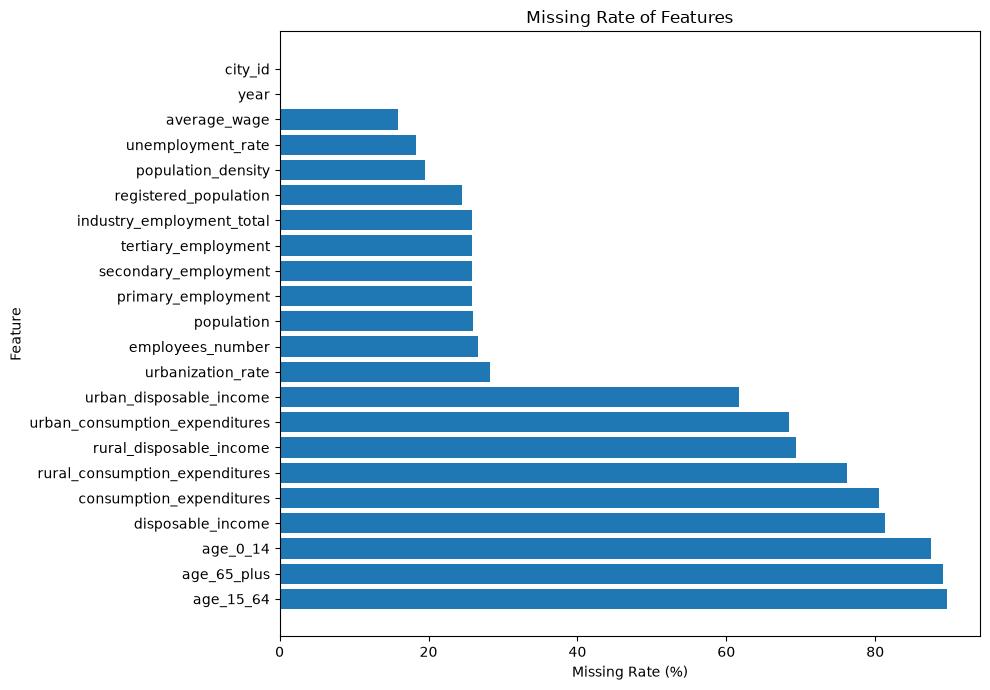

In [418]:
missing_plot = (
    missing_report
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(10, 7))

plt.barh(
    missing_plot["feature"],
    missing_plot["missing_rate"]
)

plt.xlabel("Missing Rate (%)")
plt.ylabel("Feature")
plt.title("Missing Rate of Features")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "01_missing_rate.png",
    dpi=300
)

plt.show()

# 图1 检查每年到底有多少城市有人口数据

In [419]:
population_coverage = (
    master
    .groupby("year")["population"]
    .count()
    .reset_index(name="city_count")
)

population_coverage

population_coverage.to_csv(
    DATA_DIR + "population_year_coverage.csv",
    index=False
)

# 图 2：各年份人口数据覆盖城市数

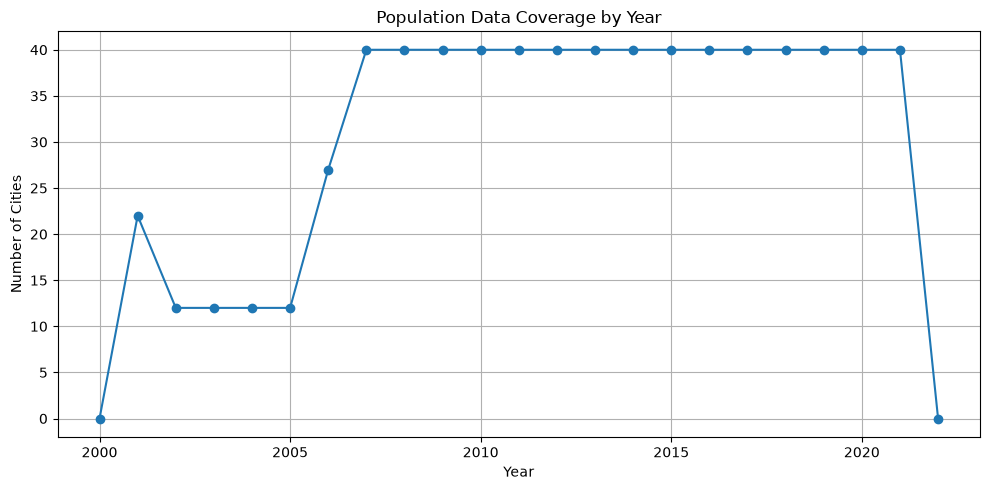

In [420]:
plt.figure(figsize=(10, 5))

plt.plot(
    population_coverage["year"],
    population_coverage["city_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Cities")
plt.title("Population Data Coverage by Year")

plt.grid()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "02_population_coverage.png",
    dpi=300
)

plt.show()

# 图 3：各年份样本城市平均人口

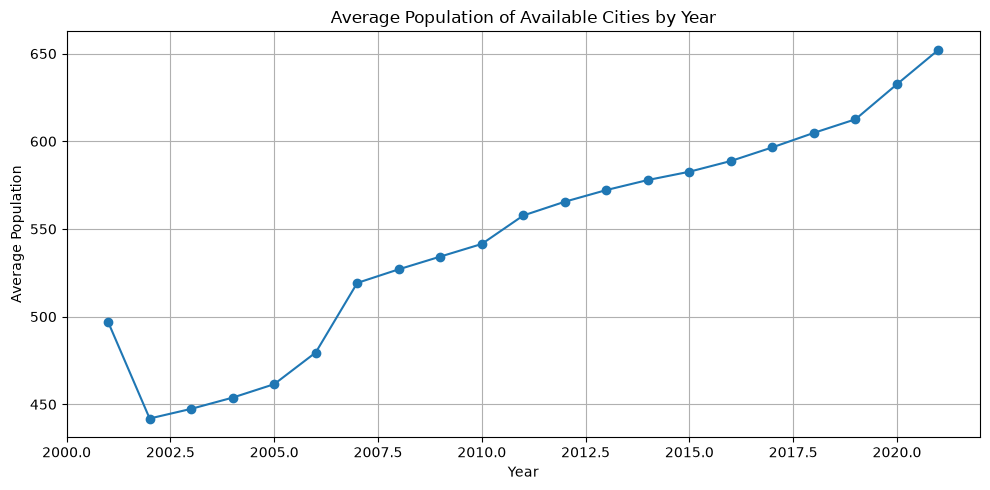

In [421]:
population_year = (
    master
    .groupby("year")["population"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    population_year["year"],
    population_year["population"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Population")
plt.title("Average Population of Available Cities by Year")

plt.grid()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "03_average_population_trend.png",
    dpi=300
)

plt.show()


# 查看不同城市的人口趋势

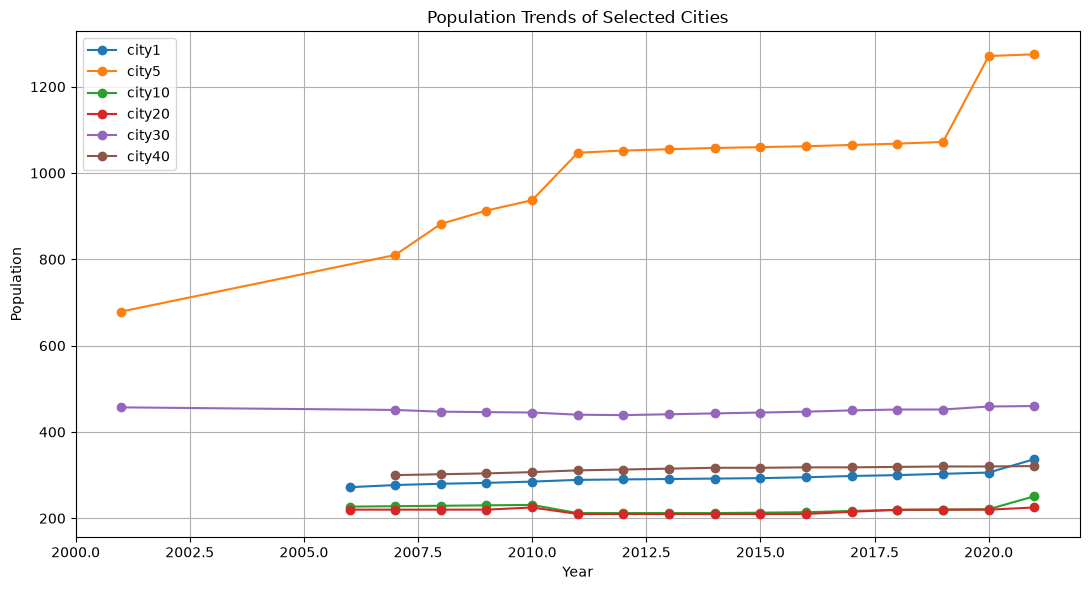

In [422]:
selected_cities = [
    "city1",
    "city5",
    "city10",
    "city20",
    "city30",
    "city40"
]

plt.figure(figsize=(11, 6))

for city in selected_cities:

    city_data = (
        master[
            master["city_id"] == city
        ]
        .dropna(subset=["population"])
        .sort_values("year")
    )

    plt.plot(
        city_data["year"],
        city_data["population"],
        marker="o",
        label=city
    )

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Trends of Selected Cities")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "04_selected_city_population.png",
    dpi=300
)

plt.show()

# 正式检查人口年份连续性

In [423]:
population_eda = (
    master
    .dropna(subset=["population"])
    .sort_values(
        ["city_id", "year"]
    )
    .copy()
)

population_eda["previous_year"] = (
    population_eda
    .groupby("city_id")["year"]
    .shift(1)
)

population_eda["year_gap"] = (
    population_eda["year"]
    - population_eda["previous_year"]
)

population_eda[
    "year_gap"
].value_counts().sort_index()



year_gap
1.0    647
6.0     10
Name: count, dtype: int64

# 找出所有年份断档

In [424]:
population_gaps = population_eda[
    population_eda["year_gap"] > 1
][
    [
        "city_id",
        "previous_year",
        "year",
        "year_gap",
        "population"
    ]
]

population_gaps


population_gaps.to_csv(
    DATA_DIR + "population_year_gaps.csv",
    index=False
)

# 计算同比人口增长率 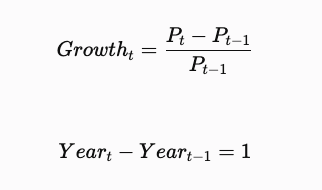

In [425]:
population_eda["previous_population"] = (
    population_eda
    .groupby("city_id")["population"]
    .shift(1)
)
# 只对year_gap==1

population_eda["population_growth"] = np.where(

    (
        (population_eda["year_gap"] == 1) &
        (population_eda["previous_population"] > 0)
    ),

    (
        population_eda["population"]
        - population_eda["previous_population"]
    )
    / population_eda["previous_population"],

    np.nan
)

# 增长率基本情况



In [426]:
population_eda["population_growth_pct"] = (
    population_eda["population_growth"] * 100
)

population_eda[
    "population_growth_pct"
].describe()

count    642.000000
mean       1.351105
std        2.641039
min       -8.225108
25%        0.168990
50%        0.641032
75%        1.783730
max       25.892857
Name: population_growth_pct, dtype: float64

# 人口增长最快的记录

In [427]:
growth_top = population_eda.nlargest(
    10,
    "population_growth"
)[
    [
        "city_id",
        "year",
        "previous_population",
        "population",
        "population_growth_pct"
    ]
]

growth_top

,city_id,year,previous_population,population,population_growth_pct
251,city19,2021,560.0,705.0,25.892857
388,city24,2020,746.0,891.0,19.436997
822,city5,2020,1072.0,1271.0,18.563433
320,city21,2021,1036.0,1194.0,15.250965
44,city10,2021,221.0,251.0,13.574661
273,city2,2020,657.0,745.0,13.394216
607,city33,2011,808.0,912.0,12.871287
67,city11,2021,480.0,540.0,12.500000
813,city5,2011,937.0,1047.0,11.739594
227,city18,2020,470.0,525.0,11.702128


下降最大的

In [428]:
growth_bottom = population_eda.nsmallest(
    10,
    "population_growth"
)[
    [
        "city_id",
        "year",
        "previous_population",
        "population",
        "population_growth_pct"
    ]
]

growth_bottom

growth_top.to_csv(
    DATA_DIR + "population_growth_top10.csv",
    index=False
)

growth_bottom.to_csv(
    DATA_DIR + "population_growth_bottom10.csv",
    index=False
)

# 图5 城镇化率与人口

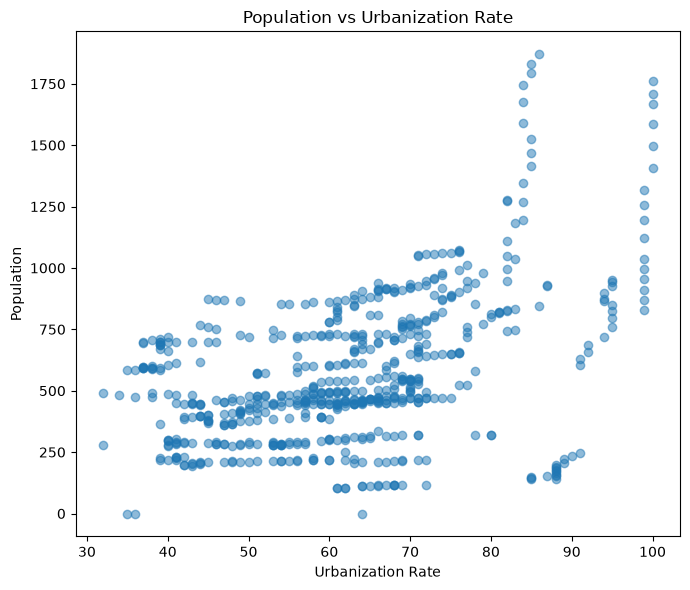

In [429]:
urban_data = master[
    [
        "population",
        "urbanization_rate"
    ]
].dropna()

plt.figure(figsize=(7, 6))

plt.scatter(
    urban_data["urbanization_rate"],
    urban_data["population"],
    alpha=0.5
)

plt.xlabel("Urbanization Rate")
plt.ylabel("Population")
plt.title("Population vs Urbanization Rate")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "05_population_urbanization.png",
    dpi=300
)

plt.show()

# 图 6：工资与人口

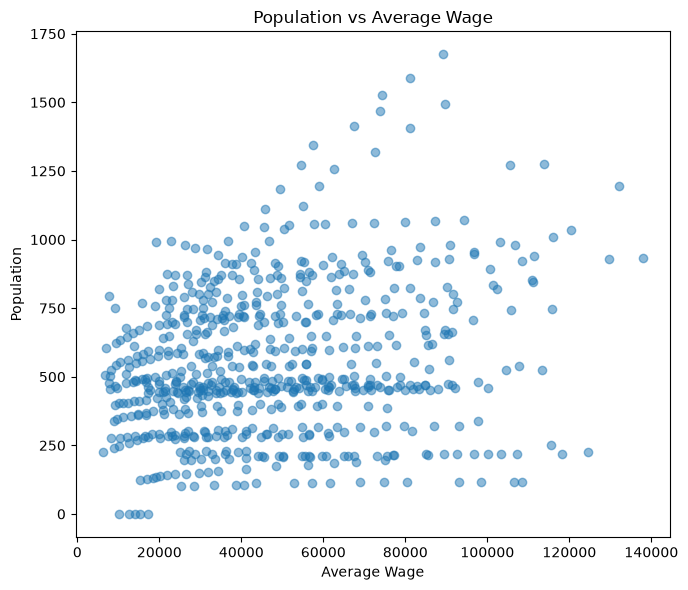

In [430]:
wage_data = master[
    [
        "population",
        "average_wage"
    ]
].dropna()

plt.figure(figsize=(7, 6))

plt.scatter(
    wage_data["average_wage"],
    wage_data["population"],
    alpha=0.5
)

plt.xlabel("Average Wage")
plt.ylabel("Population")
plt.title("Population vs Average Wage")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "06_population_wage.png",
    dpi=300
)

plt.show()

#可以比较：工资与人口是否有明显线性关系。

相关性分析（先选比较核心的变量）

In [431]:
features = [
    "population",
    "registered_population",
    "urbanization_rate",
    "population_density",
    "average_wage",
    "unemployment_rate",
    "employees_number",
    "primary_employment",
    "secondary_employment",
    "tertiary_employment"
]


features = [
    feature
    for feature in features
    if feature in master.columns
]

corr = master[
    features
].corr()

corr

corr.to_csv(
    DATA_DIR + "correlation_matrix.csv"
)

# 图 7：相关性矩阵

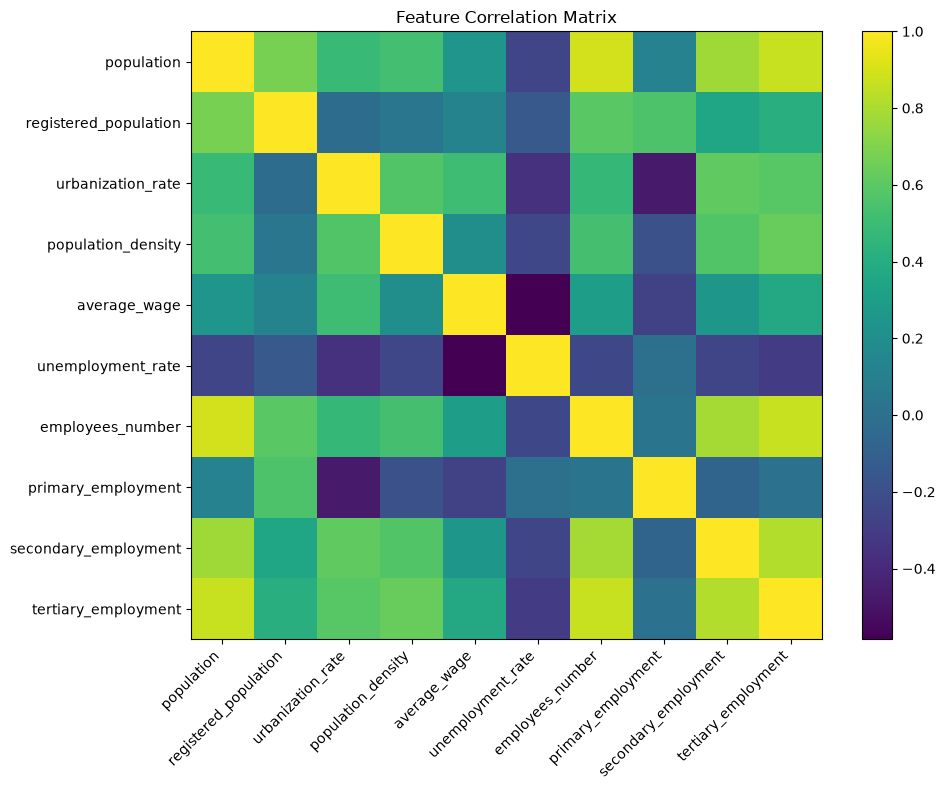

In [432]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.title(
    "Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "07_correlation_matrix.png",
    dpi=300
)

plt.show()

In [433]:
population_corr = (
    corr["population"]
    .sort_values(
        ascending=False
    )
)

population_corr

population               1.000000
employees_number         0.891655
tertiary_employment      0.864275
secondary_employment     0.776134
registered_population    0.672550
population_density       0.526961
urbanization_rate        0.485061
average_wage             0.243127
primary_employment       0.119724
unemployment_rate       -0.256251
Name: population, dtype: float64

# 这段放ppt
部分城市在特定年份存在较大的同比人口变化，例如部分记录的年度增幅超过 10%，或年度降幅超过 5%。这些记录在后续建模前作为异常变化候选进行检查，但不在缺乏进一步证据的情况下直接删除。


In [434]:
population_change_candidates = population_eda[
    (
        population_eda["population_growth_pct"] > 10
    )
    |
    (
        population_eda["population_growth_pct"] < -5
    )
][
    [
        "city_id",
        "year",
        "previous_population",
        "population",
        "population_growth_pct"
    ]
].sort_values(
    "population_growth_pct",
    ascending=False
)

population_change_candidates

,city_id,year,previous_population,population,population_growth_pct
251,city19,2021,560.0,705.0,25.892857
388,city24,2020,746.0,891.0,19.436997
822,city5,2020,1072.0,1271.0,18.563433
320,city21,2021,1036.0,1194.0,15.250965
44,city10,2021,221.0,251.0,13.574661
273,city2,2020,657.0,745.0,13.394216
607,city33,2011,808.0,912.0,12.871287
67,city11,2021,480.0,540.0,12.500000
813,city5,2011,937.0,1047.0,11.739594
227,city18,2020,470.0,525.0,11.702128



# 这段放ppt
为便于人工检查，本项目将同比增幅超过 10% 或降幅超过 5% 的记录列为重点检查对象。

# 这段放eda结论
三条正式结论

第一条：

不同数据源的年份覆盖范围存在差异，人口数据中部分城市在 2001 至 2007 年之间存在明显时间断档，因此年度变化计算必须要求连续年份。

第二条：

数据中存在人口值为 0 的记录，使普通增长率计算出现无穷值，因此增长率计算需同时满足前一年人口大于 0。

第三条：

多个城市存在较大的连续年度人口增减变化，目前将其作为重点检查对象，而不是直接作为错误记录删除。

In [435]:
master[
    master["population"] == 0
][
    ["city_id", "year", "population"]
]



,city_id,year,population
459,city28,2001,0.0
460,city28,2002,0.0
461,city28,2003,0.0
462,city28,2004,0.0
463,city28,2005,0.0


In [436]:
growth_top


,city_id,year,previous_population,population,population_growth_pct
251,city19,2021,560.0,705.0,25.892857
388,city24,2020,746.0,891.0,19.436997
822,city5,2020,1072.0,1271.0,18.563433
320,city21,2021,1036.0,1194.0,15.250965
44,city10,2021,221.0,251.0,13.574661
273,city2,2020,657.0,745.0,13.394216
607,city33,2011,808.0,912.0,12.871287
67,city11,2021,480.0,540.0,12.500000
813,city5,2011,937.0,1047.0,11.739594
227,city18,2020,470.0,525.0,11.702128


In [437]:

population_change_candidates


,city_id,year,previous_population,population,population_growth_pct
251,city19,2021,560.0,705.0,25.892857
388,city24,2020,746.0,891.0,19.436997
822,city5,2020,1072.0,1271.0,18.563433
320,city21,2021,1036.0,1194.0,15.250965
44,city10,2021,221.0,251.0,13.574661
273,city2,2020,657.0,745.0,13.394216
607,city33,2011,808.0,912.0,12.871287
67,city11,2021,480.0,540.0,12.500000
813,city5,2011,937.0,1047.0,11.739594
227,city18,2020,470.0,525.0,11.702128


# 看 city28 的完整人口序列

主要看：
2001–2005 = 0
2006 开始恢复正常

In [438]:
city28_check = population_eda[
    population_eda["city_id"] == "city28"
][
    [
        "city_id",
        "year",
        "population",
        "previous_year",
        "previous_population",
        "year_gap",
        "population_growth_pct"
    ]
]

city28_check

city28_check.to_csv(
    DATA_DIR + "city28_population_check.csv",
    index=False
)

# “人口 vs 城镇化率”散点图
检查“人口与城镇化率之间是否存在相关趋势”

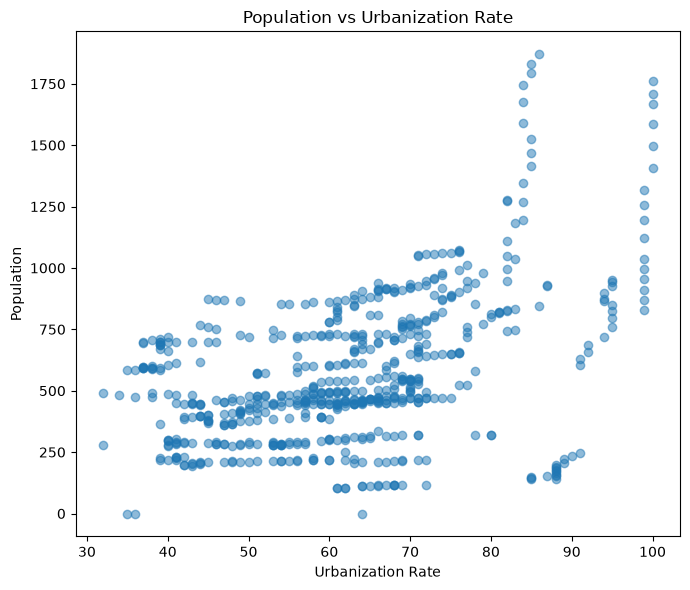

In [439]:
urban_data = master[
    ["population", "urbanization_rate"]
].dropna()

urban_data.head()


plt.figure(figsize=(7, 6))

plt.scatter(
    urban_data["urbanization_rate"],
    urban_data["population"],
    alpha=0.5
)

plt.xlabel("Urbanization Rate")
plt.ylabel("Population")
plt.title("Population vs Urbanization Rate")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "05_population_urbanization.png",
    dpi=300
)

plt.show()



# “人口 vs 工资”散点图

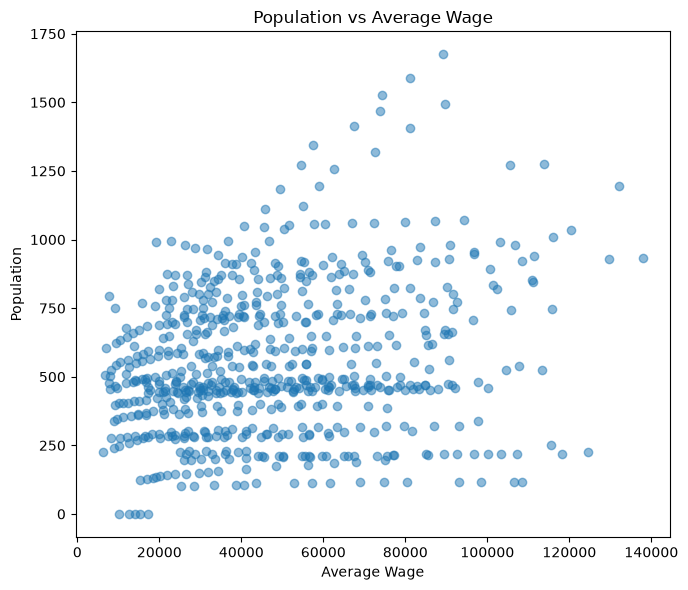

In [440]:
wage_data = master[
    ["population", "average_wage"]
].dropna()

wage_data.head()

plt.figure(figsize=(7, 6))

plt.scatter(
    wage_data["average_wage"],
    wage_data["population"],
    alpha=0.5
)

plt.xlabel("Average Wage")
plt.ylabel("Population")
plt.title("Population vs Average Wage")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "06_population_wage.png",
    dpi=300
)

plt.show()

# “人口 vs 从业人数”散点图

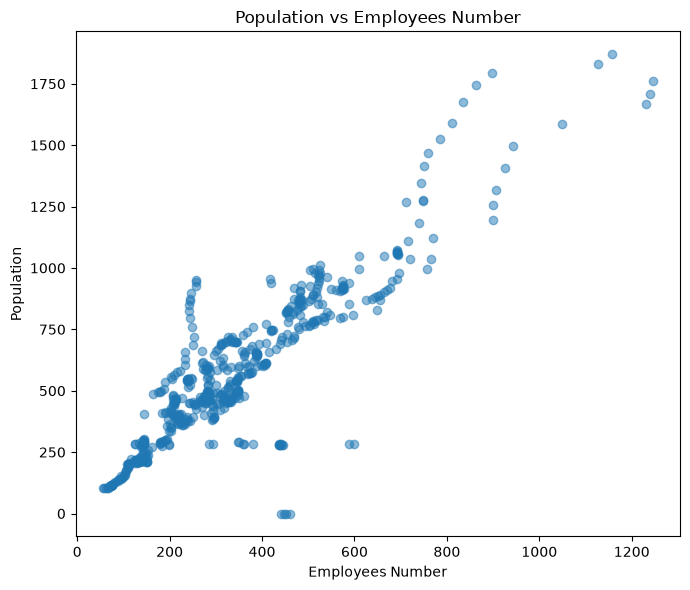

In [441]:
employment_data = master[
    ["population", "employees_number"]
].dropna()

employment_data.head()

plt.figure(figsize=(7, 6))

plt.scatter(
    employment_data["employees_number"],
    employment_data["population"],
    alpha=0.5
)

plt.xlabel("Employees Number")
plt.ylabel("Population")
plt.title("Population vs Employees Number")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "07_population_employees.png",
    dpi=300
)

plt.show()

# 部分数据相关性分析

In [442]:
features = [
    "population",
    "registered_population",
    "urbanization_rate",
    "population_density",
    "average_wage",
    "unemployment_rate",
    "employees_number",
    "primary_employment",
    "secondary_employment",
    "tertiary_employment"
]

features = [
    col for col in features
    if col in master.columns
]


corr = master[features].corr()

corr


corr.to_csv(
    DATA_DIR + "correlation_matrix.csv"
)

# 画相关性矩阵图

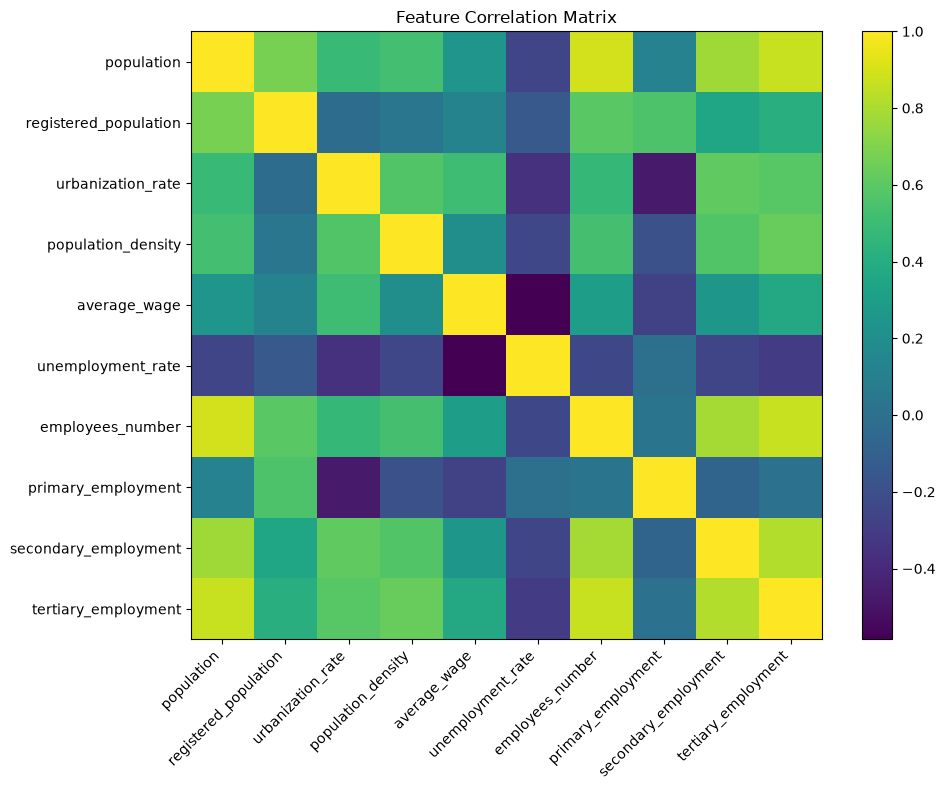

In [443]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "08_correlation_matrix.png",
    dpi=300
)

plt.show()

# 与 population 的相关程度

In [444]:
population_corr = (
    corr["population"]
    .sort_values(ascending=False)
)

population_corr

population               1.000000
employees_number         0.891655
tertiary_employment      0.864275
secondary_employment     0.776134
registered_population    0.672550
population_density       0.526961
urbanization_rate        0.485061
average_wage             0.243127
primary_employment       0.119724
unemployment_rate       -0.256251
Name: population, dtype: float64

# eda总结

In [445]:
eda_summary = pd.DataFrame({
    "item": [
        "total_rows",
        "city_count",
        "year_min",
        "year_max",
        "population_non_null",
        "population_zero_count",
        "population_gap_records",
        "candidate_change_records"
    ],
    "value": [
        len(master),
        master["city_id"].nunique(),
        master["year"].min(),
        master["year"].max(),
        master["population"].notna().sum(),
        (master["population"] == 0).sum(),
        len(population_gaps),
        len(population_change_candidates)
    ]
})

eda_summary

eda_summary.to_csv(
    DATA_DIR + "eda_summary.csv",
    index=False
)

# 几个结论，做ppt时思考一下怎么配图

结论 1

不同数据源的年份覆盖和城市覆盖范围不同，因此总表中存在明显的结构性缺失。

结论 2

人口数据在部分城市存在年份断档，例如若干城市从 2001 年直接跳到 2007 年，因此人口同比增长率只能在连续年份之间计算。

结论 3

个别城市存在连续多年的 0 人口记录，例如 city28 的 2001–2005 年数据，这类记录在增长率分析中应视为特殊情况处理。

结论 4

不同城市的人口规模和变化趋势差异明显，部分城市在个别年份存在较大的人口增减幅度，需要作为重点检查对象。

结论 5

人口与城镇化率、工资、从业人数等变量可能存在一定相关关系，这些变量可作为后续预测阶段的候选特征。